In [1]:
#load Libraries
import pandas as pd                           
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#The required Python libraries are imported:
#Pandas for data loading and manipulation
#NumPy for numerical calculations
#Matplotlib for visualization
#Seaborn for statistical visualization

In [2]:
# Set visualization style
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Supermart Grocery Sales - Retail Analytics Dataset.csv")

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    errors="coerce"
)

# Display first 5 rows
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu


In [6]:
#Check Dataset Shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 9994
Number of columns: 11
Dataset shape: (9994, 11)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Customer Name  9994 non-null   object        
 2   Category       9994 non-null   object        
 3   Sub Category   9994 non-null   object        
 4   City           9994 non-null   object        
 5   Order Date     9994 non-null   datetime64[ns]
 6   Region         9994 non-null   object        
 7   Sales          9994 non-null   int64         
 8   Discount       9994 non-null   float64       
 9   Profit         9994 non-null   float64       
 10  State          9994 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 859.0+ KB


In [9]:
#Check Missing Values
missing_values = df.isnull().sum()

print(missing_values)

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64


In [10]:
#Check Duplicate Rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
#Statistical Summary
df.describe()

,Order Date,Sales,Discount,Profit
count,9994,9994.000000,9994.000000,9994.000000
mean,2017-04-30 05:17:08.056834048,1496.596158,0.226817,374.937082
min,2015-01-03 00:00:00,500.000000,0.100000,25.250000
25%,2016-05-23 00:00:00,1000.000000,0.160000,180.022500
50%,2017-06-26 00:00:00,1498.000000,0.230000,320.780000
75%,2018-05-14 00:00:00,1994.750000,0.290000,525.627500
max,2018-12-30 00:00:00,2500.000000,0.350000,1120.950000
std,NaN,577.559036,0.074636,239.932881


In [12]:
#Value Counts for categorical variables
print("Category Distribution:")
print(df["Category"].value_counts())

Category Distribution:
Category
Snacks               1514
Eggs, Meat & Fish    1490
Fruits & Veggies     1418
Bakery               1413
Beverages            1400
Food Grains          1398
Oil & Masala         1361
Name: count, dtype: int64


In [13]:
#Check unique categories
print("Number of categories:", df["Category"].nunique())
print("\nCategories:")
print(df["Category"].unique())
# find 7 major product categories

Number of categories: 7

Categories:
['Oil & Masala' 'Beverages' 'Food Grains' 'Fruits & Veggies' 'Bakery'
 'Snacks' 'Eggs, Meat & Fish']


In [14]:
#Total Sales and Profit
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
#The business generated approximately 14.96 million in sales and 3.75 million in profit during the period represented by the dataset

Total Sales: 14956982
Total Profit: 3747121.2


In [15]:
#Profit Margin
profit_margin = (total_profit / total_sales) * 100
print("Overall Profit Margin:", round(profit_margin, 2), "%")
#The overall profit-to-sales ratio is approximately 25.1%, indicating that the business retains roughly 25 units of profit for every 100 units of sales

Overall Profit Margin: 25.05 %


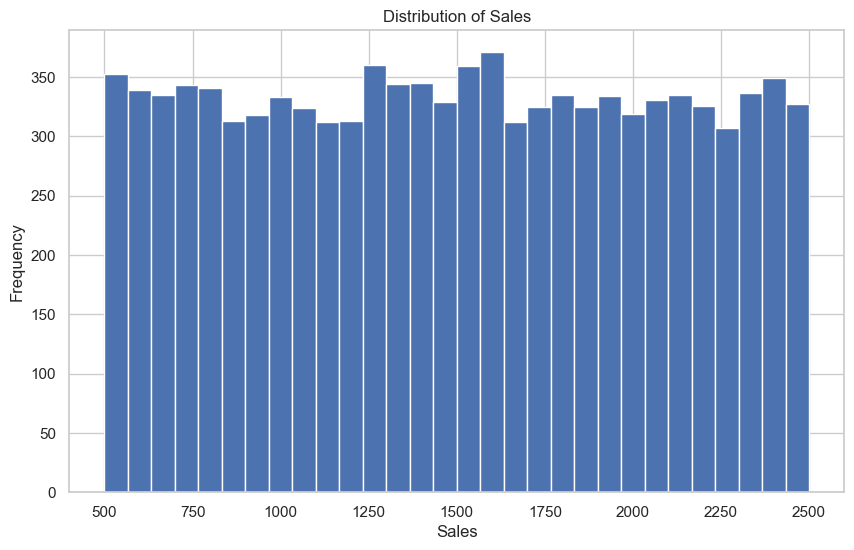

In [16]:
#Histogram  for Sales Distribution
plt.figure(figsize=(10, 6))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()
#The Sales values are fairly evenly distributed across the range of approximately 500 to 2500
#The frequency of transactions remains relatively similar across different sales ranges
#indicating no strong concentration or skewness in the Sales distribution

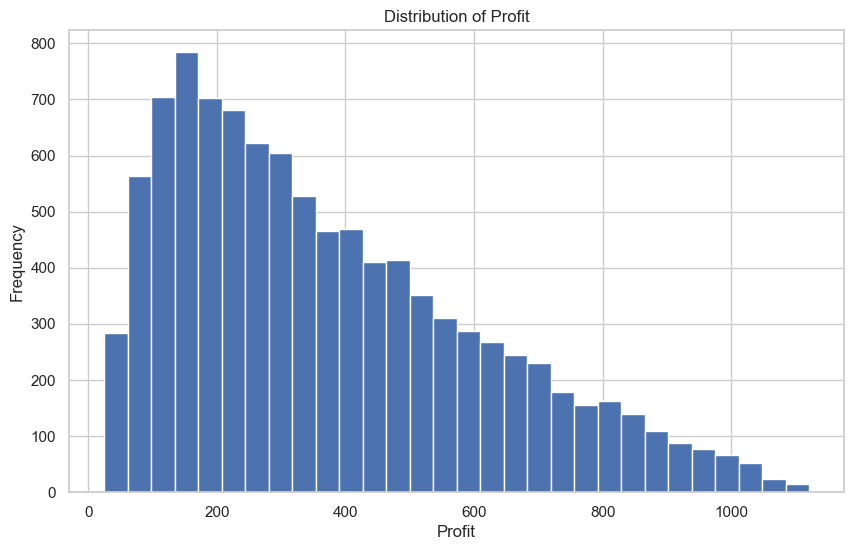

In [17]:
#HISTOGRAM for Profit Distribution
plt.figure(figsize=(10, 6))
plt.hist(df["Profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()
#The profit distribution is right-skewed
#with most transactions concentrated in the low-to-medium profit range
#Higher profit values occur less frequently
#resulting in a long right tail

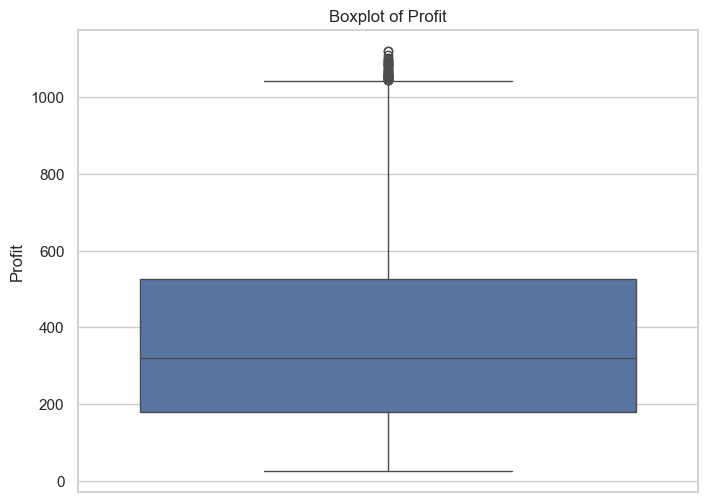

In [19]:
#BOXPLOT for Profit
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["Profit"])
plt.title("Boxplot of Profit")
plt.ylabel("Profit")
plt.show()
#The boxplot shows that most Profit values are concentrated between approximately 180 and 520
#The median Profit is around 320
#There are several high-value outliers above the upper whisker
#indicating that a small number of transactions have unusually high profits

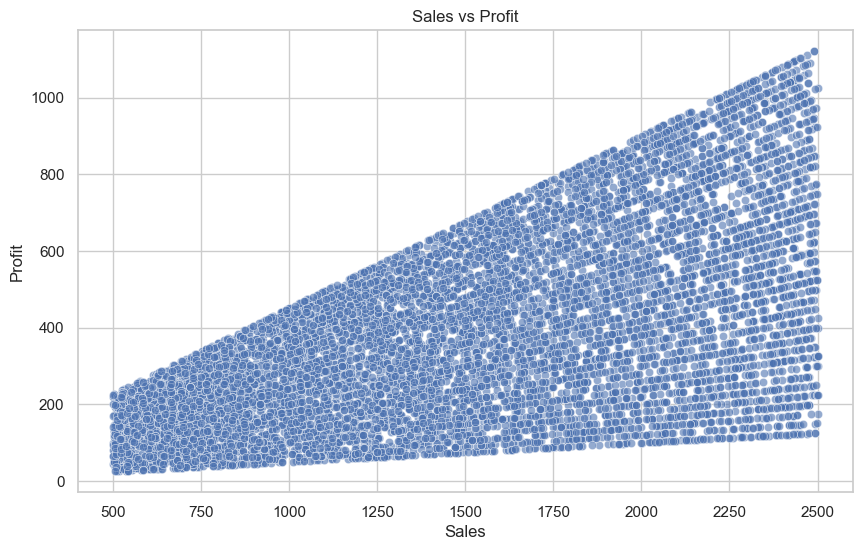

In [22]:
#SCATTERPLOT – Sales vs Profit
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.6
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()
#The scatterplot shows a clear positive relationship between Sales and Profit
#As Sales increase, Profit also tends to increase
#Higher Sales values are generally associated with higher Profit values
#indicating that increased sales are linked to greater profitability

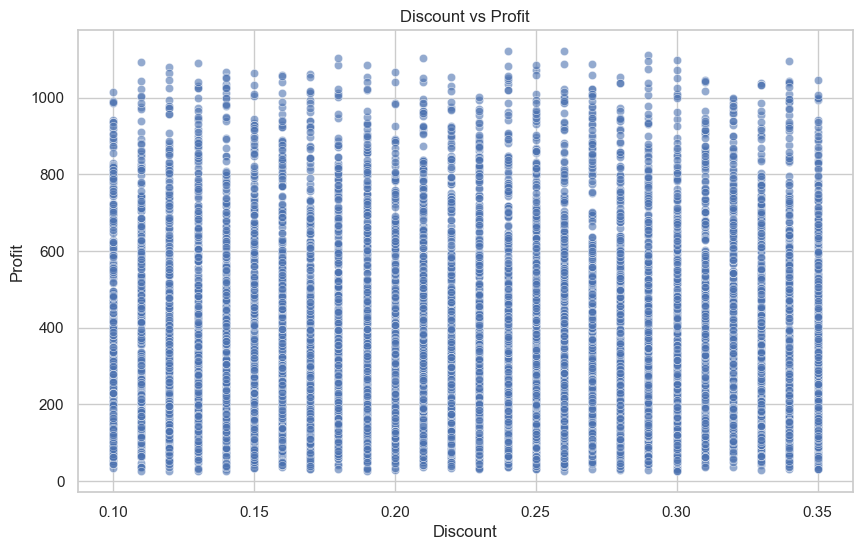

In [23]:
#SCATTERPLOT – Discount vs Profit
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()
#The scatterplot shows that there is no clear linear relationship between Discount and Profit
#Profit values are widely spread across all discount levels
#and increasing the discount does not consistently increase or decrease profit
#Therefore, Discount appears to have a weak relationship with Profit in this dataset

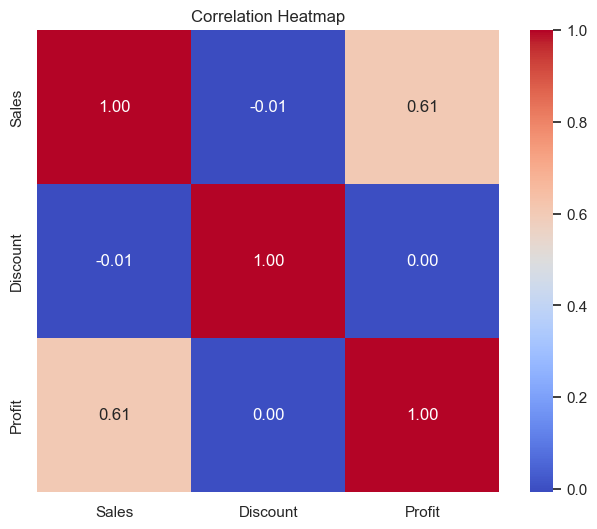

In [35]:
#CORRELATION HEATMAP
# Correlation Matrix
correlation = df[["Sales", "Discount", "Profit"]].corr()

correlation
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap")

plt.show()
#The correlation heatmap shows a moderate positive correlation between Sales and Profit (0.61)
#Discount has almost no correlation with Sales (-0.01) or Profit (0.00)
#This indicates that higher Sales are generally associated with higher Profit
#while Discount has little to no linear relationship with Sales or Profit

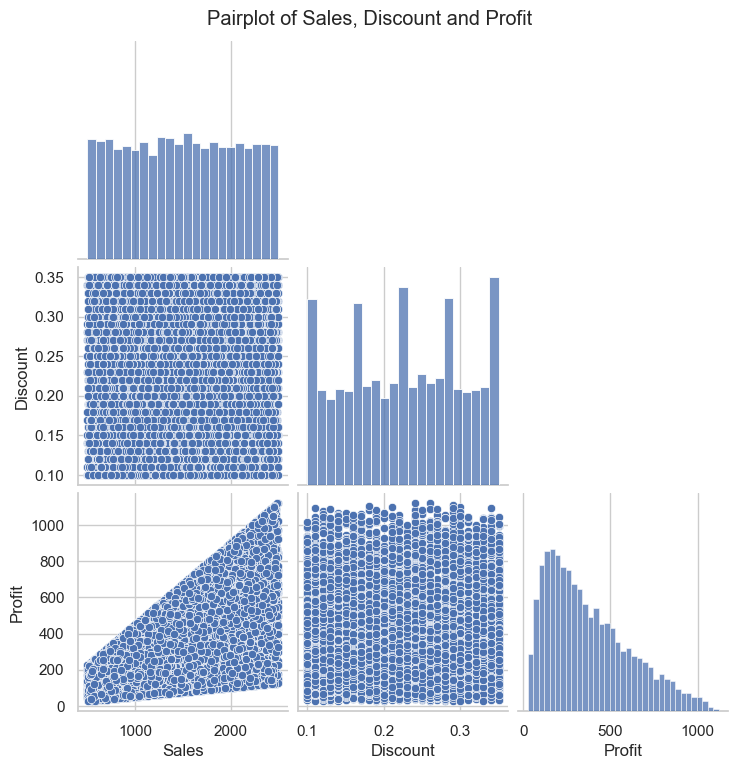

In [28]:
#PAIRPLOT
sns.pairplot(
    df[["Sales", "Discount", "Profit"]],
    corner=True
)

plt.suptitle(
    "Pairplot of Sales, Discount and Profit",
    y=1.02
)

plt.show()
#Sales and Profit have a positive relationship,
#while Discount has little or no relationship with Sales and Profit

In [29]:
#SALES BY CATEGORY
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Eggs, Meat & Fish    2267401
Snacks               2237546
Food Grains          2115272
Bakery               2112281
Fruits & Veggies     2100727
Beverages            2085313
Oil & Masala         2038442
Name: Sales, dtype: int64


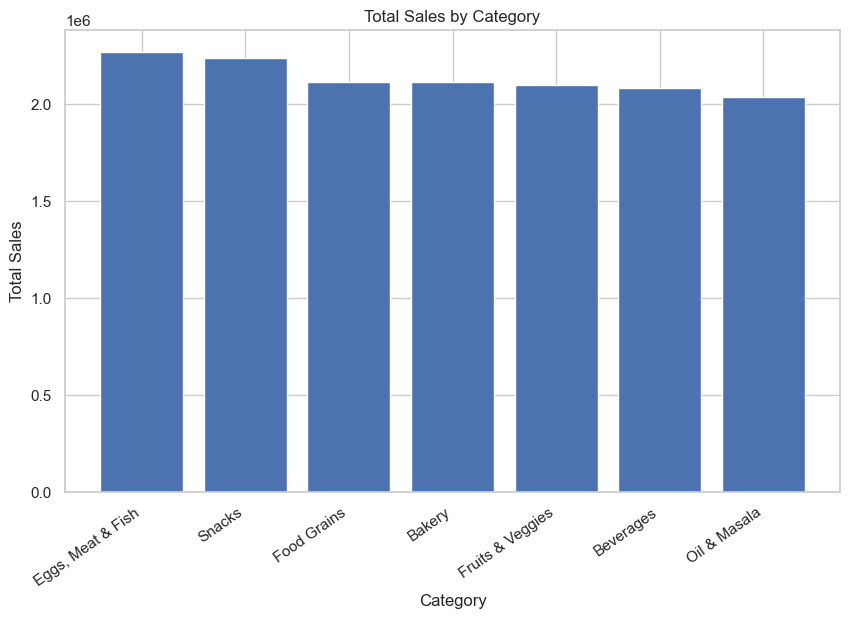

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=35, ha="right")

plt.show()
#Eggs, Meat & Fish has the highest total sales, 
#while Oil & Masala has the lowest. Overall, sales are fairly evenly distributed across categories


In [31]:
#SALES BY REGION
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       4798743
East       4248368
Central    3468156
South      2440461
North         1254
Name: Sales, dtype: int64


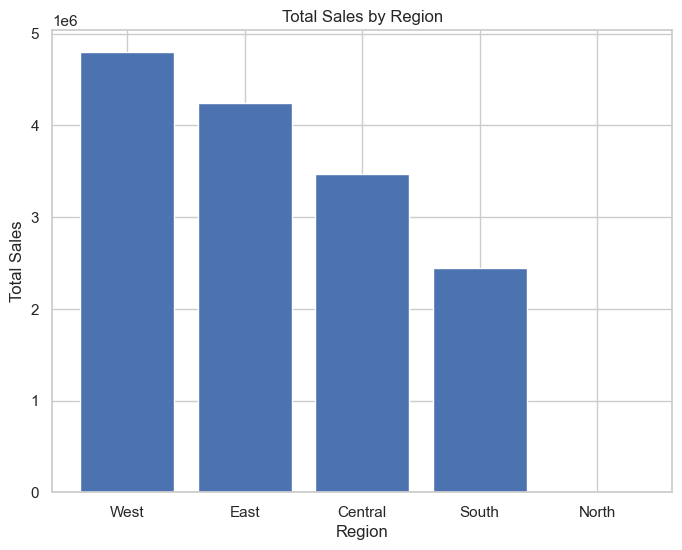

In [32]:
plt.figure(figsize=(8, 6))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()
#The West region has the highest total sales,
#while the North region has the lowest
#The East and Central regions also show strong sales, with South having lower sales than the other major regions


In [33]:
#YEARLY SALES TREND
df["Year"] = df["Order Date"].dt.year

yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

print(yearly_sales)

Year
2015    2975599
2016    3131959
2017    3871912
2018    4977512
Name: Sales, dtype: int64


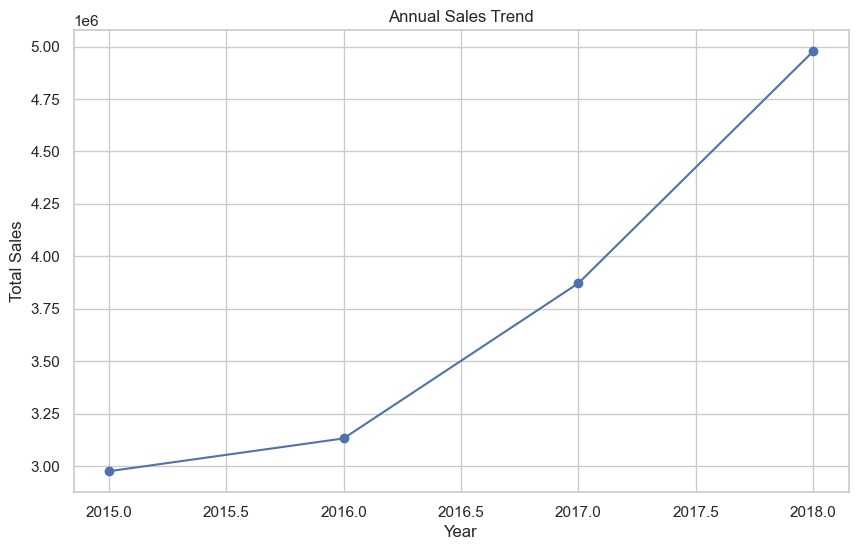

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()
#Annual sales show a clear increasing trend from 2015 to 2018, with the highest sales recorded in 2018.**
